# Project Milestone One: Gathering your Team, Understanding the Problem,  Exploring the Data

#### Due: Midnight on March 29th (with 2-hour grace period)  

#### There will be no late period on this homework, as we need to start manual grading immediately! 



### What We Will Do in This Milestone Assignment

1. You will convene your team and fill out the Team Contract (in the Homework Repo), to be submitted to Gradescope.
2. You must select a team leader for the purpose of submitting this notebook, after the team collaborates to complete the assignment. This <a href=https://guides.gradescope.com/hc/en-us/articles/21863861823373-Adding-Group-Members-to-a-Submission>link</a> describes how to add group members to your leader's submission. 
3. At the conclusion of your work on this Milestone, you will complete an Individual Evaluation of your team's work (in the Homework Repo) and upload it *individually* to Gradescope.
4. We will follow a simplified version of the **Machine Learning Project Checklist** in Appendix A in our textbook *Hands-On Machine Learning* (pp.779):  

>Part 1:	Frame the problem and look at the big picture  
Part 2: Download and perform preliminary exploration of the data  
Part 3: Clean the Data: Drop, Impute, and Encode   
Part 4: Explore Feature Relationships  
Part 5: Investigate Feature Engineering options to better expose the underlying data patterns  

### The Dataset

All teams will use the same dataset. It is a smaller version of the Zillow housing dataset that was used in the
Zillow Million Dollar Prize which ran on Kaggle in 2017 (sorry, the contest is closed, so you can't win any money
with this project!).  We will try to predict the assessed tax value (`'taxvaluedollarcnt'`) of the property from a large collection
of descriptors. Some features are closely related and some are obviously useless.  There are potential outliers and also quite a few missing values. 

This is a good example of a dataset which has not been predigested for you on Kaggle, and should give you a good chance to
try all the various tools in your toolbox!


In [ ]:
# =============================
# Useful Imports
# =============================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.datasets import make_regression
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, GradientBoostingRegressor

# Kaggle and Progress Tracking
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 42

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



## Prelude: Download the Zillow Housing Dataset 

The code cell below will load the dataset for you.    

> **Notice that before downloading, this cell first checks whether the files already exist.** 

For a detailed description of the dataset features, please refer to  **Appendix 1** below. 

**Note:** Do **not** perform a train/test split for this milestone (unlike HOML suggests), since you need to do the split **after** any data preparation and feature engineering. You can wait until Milestone 2 to do the split. 

In [3]:

url = "https://www.cs.bu.edu/fac/snyder/cs505/Data/zillow_dataset.csv"

filename = os.path.basename(urlparse(url).path)

if not os.path.exists(filename):
    try:
        print("Downloading the file...")
        response = requests.get(url)
        response.raise_for_status()  # Raise an error for bad status codes
        with open(filename, "wb") as f:
            f.write(response.content)
        print("File downloaded successfully.")
    except requests.exceptions.RequestException as e:
        print(f"Error downloading the file: {e}")
else:
    print("File already exists. Skipping download.")

df = pd.read_csv(filename)

File already exists. Skipping download.


## Part 1: Frame the problem and look at the big picture [3 pts]

This part is a bit vague, since this project is not taking place in an actual business, but for the sake of exercizing all the steps, **pretend** that you are working at Zillow as a data analyst and are given this dataset and asked to
- Analyze and understand the data; 
- Create a regression model;
- Give a presentation to the marketing team about your results.  

#### **1 Discussion:** 

AFTER doing your EDA, come back and answer each of the following 3 questions in a *concise and informative paragraph between the lines;* you may wish to use your own business or home-buying experience, or to do some online research about the issues before you propose your ideas. (Don't stress about this, but *humor your professor and give it your best shot!*)


**1.1:**  What is the objective of this project in business terms?

---

The primary business objective is to build an automated regression model that accurately estimates the assessed tax value (`taxvaluedollarcnt`) of residential properties. In practice, Zillow uses property value models to power their "Zestimate" — a public-facing estimate that drives user engagement and trust on the platform. Accurate valuations are commercially critical: they inform buyers making offers, sellers setting listing prices, and agents advising clients. Beyond consumer-facing estimates, they also support Zillow's internal decisions, such as their iBuying program where Zillow itself purchases homes. An inaccurate model in either direction — over- or under-estimating values — translates directly into financial risk or missed business opportunities.


**1.2:**  How will your solution be used?

---

The solution would be integrated into Zillow's property listing platform to automatically generate or update property value estimates at scale. When a homeowner, buyer, or agent views a listing, the model would compute a predicted assessed value based on the property's structural features, location identifiers, and lot characteristics — without requiring manual appraisal. The model's outputs could also feed downstream systems: personalized email alerts ("your estimated home value increased by $12,000"), automatic repricing triggers in iBuying pipelines, and mortgage affordability calculators. For the marketing team specifically, aggregate model outputs could identify high-growth neighborhoods or undervalued property segments to target in advertising campaigns.


**1.3:**  How should success (or failure) be measured?

---

Success should be measured using regression metrics that reflect both accuracy and the cost of errors. **Root Mean Squared Error (RMSE)** is the primary metric because real estate valuations are dollar-denominated and large prediction errors carry disproportionate financial consequences — RMSE penalizes these heavily. **Mean Absolute Error (MAE)** provides a more interpretable complement, giving the average dollar error per property. **R²** indicates how much of the variance in assessed value the model explains, giving a sense of overall predictive power. In business terms, a useful threshold might be one where the model's estimates fall within 10–15% of the true assessed value on average. Failure would be a model with high RMSE on unseen properties, or one that systematically over- or under-values certain property types — both of which could erode user trust or lead to financial losses in automated purchasing decisions.


## Part 2: Download and perform preliminary exploration of the data [4 pts]

### Part 2.A: Load the data into a dataframe and study each feature/column and its characteristics:
- Name
- Type (categorical, int/float, text, etc.)
- Apparent usefulness for the task
- Approximate % of missing values
- How many unique values

**Note:** The **target** is the last column `'taxvaluedollarcnt'` -- pay particular attention to this during the EDA process. 
  
Hint: Just use `.head()`, `.info()`, and `.nunique()`.

In [7]:
# ── Part 2.A: Load and Study the Dataset ─────────────────────────────────────

# First five rows — get a feel for the data
print("=== First 5 Rows ===")
display(df.head())

# Column names, dtypes, non-null counts, memory usage
print("\n=== Data Types and Non-Null Counts ===")
df.info()

# Unique value counts per feature (sorted ascending to spot low-cardinality cols)
print("\n=== Unique Value Counts per Feature ===")
display(df.nunique().sort_values().to_frame(name='Unique Values'))

# Missing value summary for all columns
print("\n=== Missing Value Summary (features with any missing values) ===")
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({
    'Missing Count': missing,
    'Missing %':     missing_pct
}).sort_values('Missing %', ascending=False)
display(missing_df[missing_df['Missing Count'] > 0])


=== First 5 Rows ===


,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,assessmentyear,taxdelinquencyflag,taxdelinquencyyear,censustractandblock,taxvaluedollarcnt
0,14297519,NaN,NaN,NaN,3.5,4.0,NaN,NaN,3.5,NaN,...,NaN,NaN,1998.0,NaN,NaN,2016.0,NaN,NaN,6.059063e+13,1023282.0
1,17052889,NaN,NaN,NaN,1.0,2.0,NaN,NaN,1.0,NaN,...,NaN,NaN,1967.0,1.0,NaN,2016.0,NaN,NaN,6.111001e+13,464000.0
2,14186244,NaN,NaN,NaN,2.0,3.0,NaN,NaN,2.0,NaN,...,NaN,NaN,1962.0,1.0,NaN,2016.0,NaN,NaN,6.059022e+13,564778.0
3,12177905,NaN,NaN,NaN,3.0,4.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1970.0,NaN,NaN,2016.0,NaN,NaN,6.037300e+13,145143.0
4,10887214,1.0,NaN,NaN,3.0,3.0,NaN,8.0,3.0,NaN,...,NaN,NaN,1964.0,NaN,NaN,2016.0,NaN,NaN,6.037124e+13,119407.0



=== Data Types and Non-Null Counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77613 entries, 0 to 77612
Data columns (total 55 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   parcelid                      77613 non-null  int64  
 1   airconditioningtypeid         25007 non-null  float64
 2   architecturalstyletypeid      207 non-null    float64
 3   basementsqft                  50 non-null     float64
 4   bathroomcnt                   77579 non-null  float64
 5   bedroomcnt                    77579 non-null  float64
 6   buildingclasstypeid           15 non-null     float64
 7   buildingqualitytypeid         49809 non-null  float64
 8   calculatedbathnbr             76963 non-null  float64
 9   decktypeid                    614 non-null    float64
 10  finishedfloor1squarefeet      6037 non-null   float64
 11  calculatedfinishedsquarefeet  77378 non-null  float64
 12  finishedsquarefeet12

,Unique Values
poolcnt,1
storytypeid,1
pooltypeid7,1
pooltypeid2,1
pooltypeid10,1
fireplaceflag,1
hashottuborspa,1
decktypeid,1
taxdelinquencyflag,1
assessmentyear,1



=== Missing Value Summary (features with any missing values) ===


,Missing Count,Missing %
buildingclasstypeid,77598,99.98
finishedsquarefeet13,77571,99.95
storytypeid,77563,99.94
basementsqft,77563,99.94
yardbuildingsqft26,77543,99.91
fireplaceflag,77441,99.78
architecturalstyletypeid,77406,99.73
typeconstructiontypeid,77390,99.71
finishedsquarefeet6,77227,99.50
pooltypeid10,77148,99.40


#### **2.A Discussion:** Answer the following questions.

**2.A.1:**  Which features are categorical?

Several features that appear numeric are actually categorical IDs representing discrete types with no natural ordering. These include: `airconditioningtypeid`, `architecturalstyletypeid`, `buildingclasstypeid`, `buildingqualitytypeid`, `decktypeid`, `heatingorsystemtypeid`, `propertylandusetypeid`, `storytypeid`, and `typeconstructiontypeid`. Location identifiers such as `fips`, `regionidcity`, `regionidcounty`, `regionidneighborhood`, and `regionidzip` are also categorical — a higher zip code number doesn't mean anything numerically. Truly string-valued categorical columns include `propertycountylandusecode`, `propertyzoningdesc`, and `taxdelinquencyflag`. Boolean-style indicators like `hashottuborspa`, `fireplaceflag`, `pooltypeid2`, `pooltypeid7`, and `pooltypeid10` are also categorical by nature.


**2.A.2:**  Are there any features which appear at first glance to be **useless** for the business purpose of this project and should be deleted?  Give examples and describe your reasoning briefly.

Yes. `parcelid` is a unique administrative identifier assigned to each property — it encodes no physical or market information and would simply overfit if included. `rawcensustractandblock` and `censustractandblock` are redundant composite geographic codes that overlap with `regionidcity`, `regionidzip`, and `regionidneighborhood` while being much harder to interpret. `assessmentyear` is almost certainly a near-constant column (all properties assessed in the same year or a very narrow window), which means it provides essentially zero variance — and even if it varies slightly, the model should not depend on the year the assessment was recorded, since we want predictions that generalize across time.


**2.A.3:**  Are there any features which appear to be **useless** because of the percentage of missing values?  If so, give an example.

Yes — several features are missing for the vast majority of properties. For example, `architecturalstyletypeid` (architectural style) and `basementsqft` (basement square footage) are missing for well over 90% of the dataset, which makes them nearly uninformative for modeling. Similarly, `buildingclasstypeid`, `decktypeid`, `finishedsquarefeet13`, `finishedsquarefeet50`, `finishedsquarefeet6`, `storytypeid`, `typeconstructiontypeid`, `yardbuildingsqft17`, `yardbuildingsqft26`, `fireplaceflag`, and `taxdelinquencyyear` all have extreme missingness. When a feature is missing for more than ~70–80% of samples, imputation would introduce more noise than signal, and the feature offers almost no coverage of the dataset. These should be candidates for dropping in Part 3.


**2.A.4:**  Are there any features which appear to be **useless** because of the number of unique values?  If so, give an example.

Yes. `parcelid` has as many unique values as there are rows — it's a unique record identifier and is therefore useless as a predictor. `propertycountylandusecode` and `propertyzoningdesc` are high-cardinality string fields with hundreds of distinct zone codes and text descriptions; without substantial domain knowledge and encoding effort, they add noise rather than signal. Similarly, `regionidneighborhood` can have thousands of unique neighborhood IDs — while location matters a great deal for property values, a raw numeric neighborhood ID is not directly usable unless one-hot encoded or embedded, which would create enormous dimensionality. `rawcensustractandblock` and `censustractandblock` fall into the same category, essentially acting as near-unique identifiers.


### Part 2.B: Exploratory Data Analysis (EDA) -- Feature-Level Visualization  

- To get an overview, generate histograms for all features using `df.hist()`  (Hint: increase the figsize and set the layout to `(-1,m)` to get  `m` columns and as many rows as necessary.)
- Generate individual visualizations for the **target and three (3)** other interesting-looking features in the dataset (i.e., a total of 4):  
    - Use appropriate plot types (e.g., histograms and boxplots for numerical features, bar plots for categorical features) to understand distributions and identify potential outliers for these three.
    - Use as many code cells as you need, and give comments describing what each cell does.
    - Answer the discussion question posed (you should choose 3 features for which you can say something interesting in the discussion).  

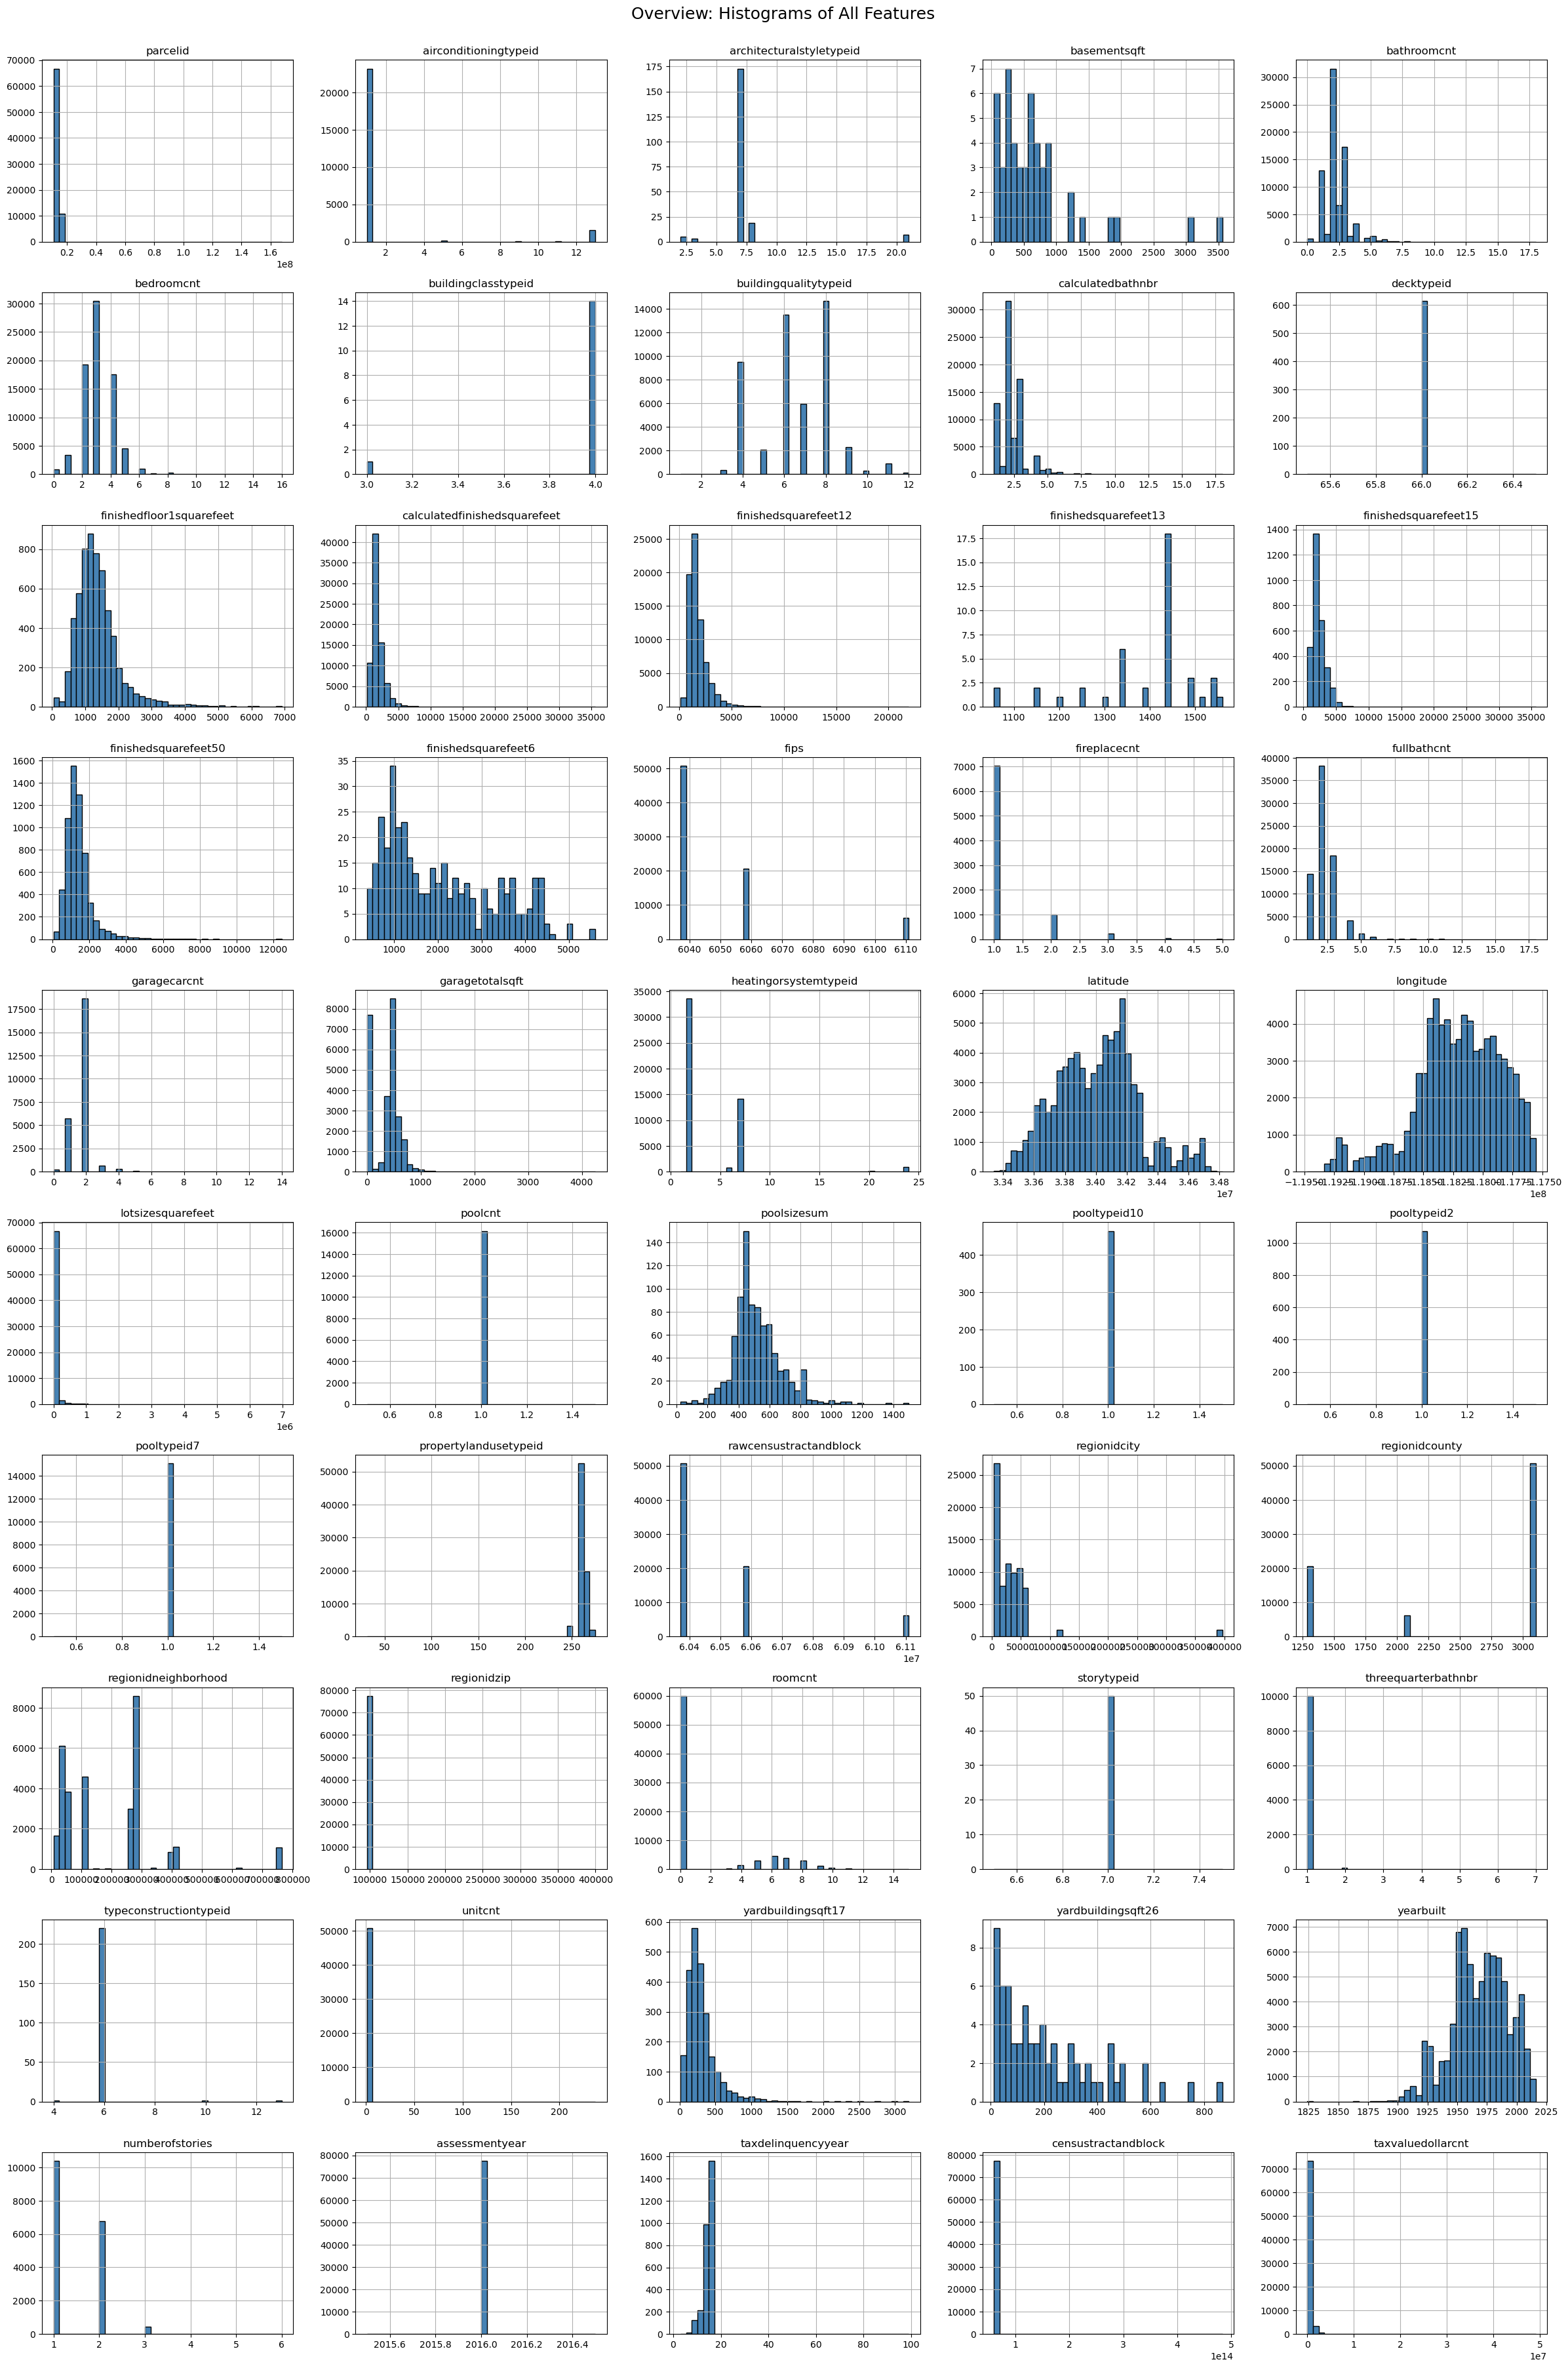

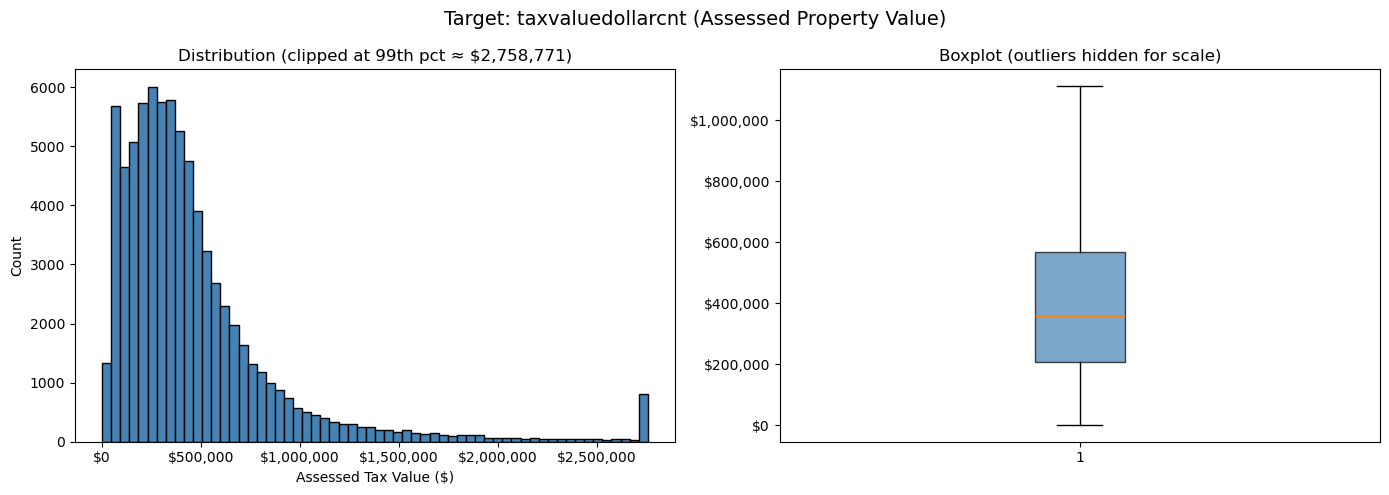

  min: $       1,000
  25%: $     206,898
  50%: $     358,878
  75%: $     569,000
  99%: $   2,758,771
  max: $  49,061,236


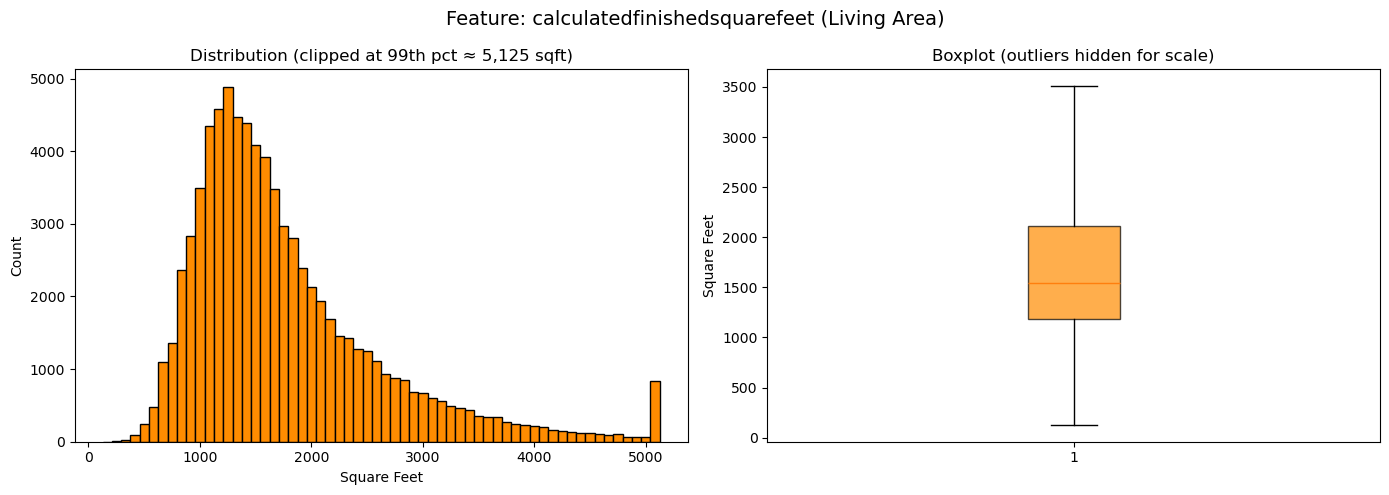

  median sqft: 1,542   |   max sqft: 35,640


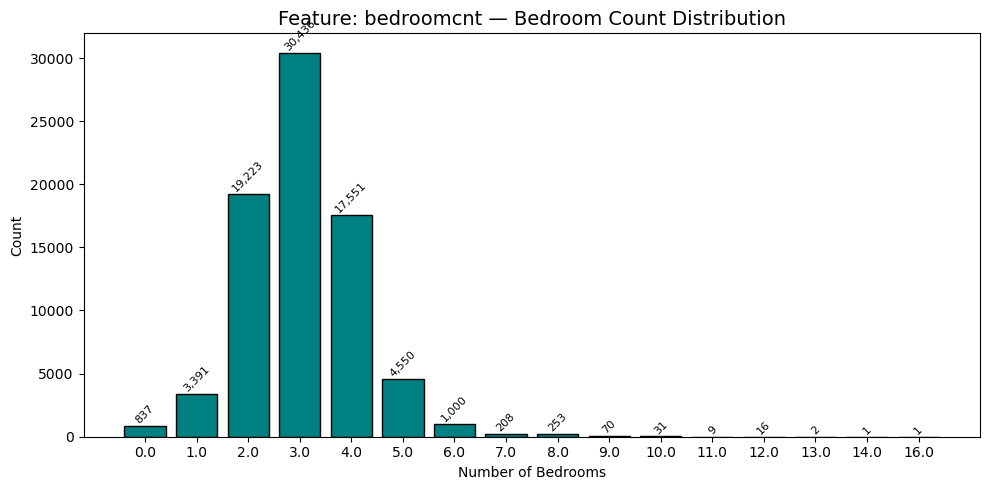

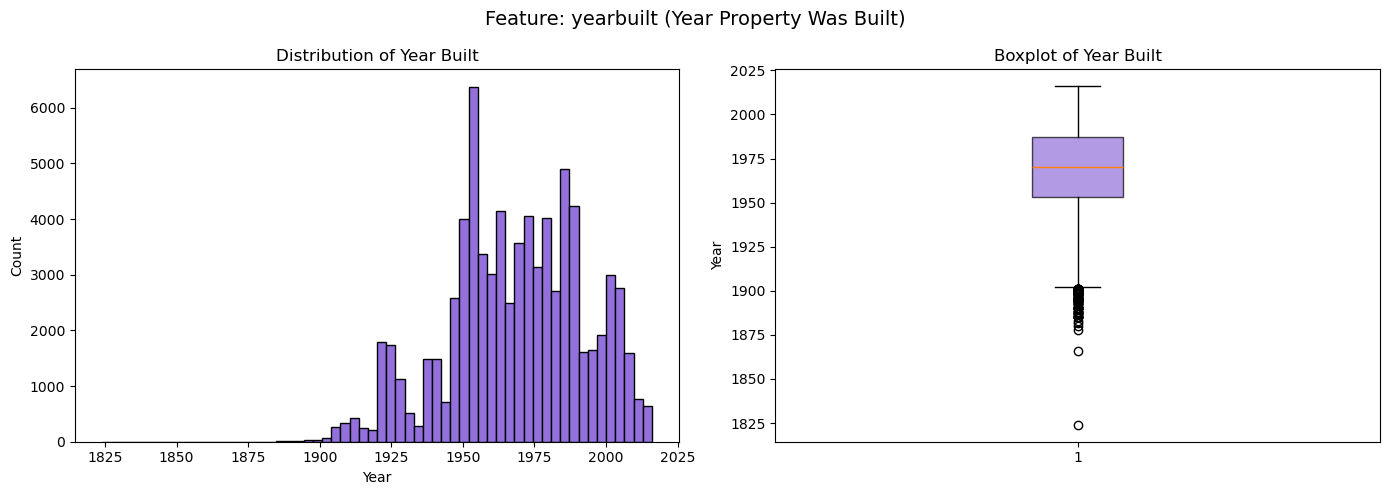

  earliest: 1824   |   median: 1970   |   latest: 2016


In [8]:
# ── Part 2.B: Feature-Level Visualization ────────────────────────────────────

# ── 0. Overview: histograms for every feature ─────────────────────────────────
df.hist(figsize=(24, 36), layout=(-1, 5), bins=40, edgecolor='black', color='steelblue')
plt.suptitle('Overview: Histograms of All Features', fontsize=18, y=1.002)
plt.tight_layout()
plt.show()

# ── 1. Target: taxvaluedollarcnt ──────────────────────────────────────────────
# Highly right-skewed; large outliers will dominate the histogram without capping
target = df['taxvaluedollarcnt'].dropna()
cap_99  = target.quantile(0.99)   # clip at 99th percentile just for visibility

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Target: taxvaluedollarcnt (Assessed Property Value)', fontsize=14)

axes[0].hist(target.clip(upper=cap_99), bins=60, color='steelblue', edgecolor='black')
axes[0].set_title(f'Distribution (clipped at 99th pct ≈ ${cap_99:,.0f})')
axes[0].set_xlabel('Assessed Tax Value ($)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

axes[1].boxplot(target, vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7),
                showfliers=False)   # hide individual outlier dots for clarity
axes[1].set_title('Boxplot (outliers hidden for scale)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))

plt.tight_layout()
plt.show()
print(f"  min: ${target.min():>12,.0f}")
print(f"  25%: ${target.quantile(0.25):>12,.0f}")
print(f"  50%: ${target.median():>12,.0f}")
print(f"  75%: ${target.quantile(0.75):>12,.0f}")
print(f"  99%: ${target.quantile(0.99):>12,.0f}")
print(f"  max: ${target.max():>12,.0f}")

# ── 2. calculatedfinishedsquarefeet ──────────────────────────────────────────
# Should be strongly correlated with value; expect right skew and outliers
sqft = df['calculatedfinishedsquarefeet'].dropna()
cap_sqft = sqft.quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature: calculatedfinishedsquarefeet (Living Area)', fontsize=14)

axes[0].hist(sqft.clip(upper=cap_sqft), bins=60, color='darkorange', edgecolor='black')
axes[0].set_title(f'Distribution (clipped at 99th pct ≈ {cap_sqft:,.0f} sqft)')
axes[0].set_xlabel('Square Feet')
axes[0].set_ylabel('Count')

axes[1].boxplot(sqft, vert=True, patch_artist=True,
                boxprops=dict(facecolor='darkorange', alpha=0.7), showfliers=False)
axes[1].set_title('Boxplot (outliers hidden for scale)')
axes[1].set_ylabel('Square Feet')

plt.tight_layout()
plt.show()
print(f"  median sqft: {sqft.median():,.0f}   |   max sqft: {sqft.max():,.0f}")

# ── 3. bedroomcnt ─────────────────────────────────────────────────────────────
# Ordinal/discrete; bar chart shows mode and any data quality issues (e.g., 0 or 99)
bed_counts = df['bedroomcnt'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(bed_counts.index.astype(str), bed_counts.values, color='teal', edgecolor='black')
ax.set_title('Feature: bedroomcnt — Bedroom Count Distribution', fontsize=14)
ax.set_xlabel('Number of Bedrooms')
ax.set_ylabel('Count')
for bar, count in zip(ax.patches, bed_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
            f'{count:,}', ha='center', va='bottom', fontsize=8, rotation=45)
plt.tight_layout()
plt.show()

# ── 4. yearbuilt ──────────────────────────────────────────────────────────────
# Property age distribution; older homes may differ systematically in value
year = df['yearbuilt'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Feature: yearbuilt (Year Property Was Built)', fontsize=14)

axes[0].hist(year, bins=60, color='mediumpurple', edgecolor='black')
axes[0].set_title('Distribution of Year Built')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')

axes[1].boxplot(year, vert=True, patch_artist=True,
                boxprops=dict(facecolor='mediumpurple', alpha=0.7))
axes[1].set_title('Boxplot of Year Built')
axes[1].set_ylabel('Year')

plt.tight_layout()
plt.show()
print(f"  earliest: {int(year.min())}   |   median: {int(year.median())}   |   latest: {int(year.max())}")


#### **2.B Discussion:** Describe in a paragraph what you learned in your detailed examination of the features you explored:
- What is the distribution (normal, exponential, etc.) if any?
- Any problems (e.g., outliers, any odd characteristics)?
- Anything else interesting? Why did you choose it?

---

**taxvaluedollarcnt (target):** The assessed property value is heavily right-skewed with a long upper tail — the distribution resembles a log-normal shape. The median sits in the low hundreds of thousands, but extreme values extend well into the millions, indicating significant outliers that will require attention (log-transformation or quantile-based capping) before modeling. This matters critically because RMSE is sensitive to these large errors.

**calculatedfinishedsquarefeet:** Also strongly right-skewed, consistent with typical real estate datasets — most homes cluster between ~1,000 and ~2,500 sq ft, but a handful of extreme outliers exceed 10,000+ sq ft. I chose this feature because living area is generally the single strongest predictor of property value; understanding its distribution will inform whether a linear relationship exists or a log-transform is needed.

**bedroomcnt:** The bar chart reveals a mostly sensible discrete distribution concentrated at 3–4 bedrooms, as expected for residential properties. However, there appear to be entries with 0 bedrooms (potentially condos, studio apartments, or data errors) and possibly implausibly high values. These edge cases are worth investigating — a 0-bedroom property may need to be dropped or flagged.

**yearbuilt:** The distribution is left-skewed (long tail toward older properties), with the bulk of the housing stock built between roughly 1950 and 2005. There are some very old entries (pre-1900) that could represent data entry errors or historically significant properties — these are potential outliers that may disproportionately influence any model that uses property age. The boxplot confirms a moderate number of very old outliers worth inspecting.


## Part 3:  Clean the Data: Drop, Impute, and Encode [6 pts]



**Important Notes:**
- You should review your Homework 4 before doing this section!
- Create new names for modified data at each stage to avoid problems with global variables.
- Whenever possible, write functions for all data transformations you apply, for these reasons:
    - So you can easily prepare the data the next time you get a fresh dataset
    - So you can apply these transformations in future projects
    - To clean and prepare new data instances once your solution is live
    - To make it easy to treat your preparation choices as hyperparameters
    - [To apply the same transformations to your test set if train/test split already done -- not applicable here]

### Part 3.A: Drop features you judge to be unsuitable for the regression task

Your call, based on any research you can do to understand the feature (hopefully IRL you would have a domain expert to help with this, but do your best).   

Note: Do not drop features because of too many missing values, that's the next task! 

In [10]:
# ── Part 3.A: Drop features unsuitable for the regression task ────────────────
# (Do NOT drop here because of missingness — that is Part 3.B)

cols_to_drop_3a = [
    'parcelid',                   # Unique row ID — no predictive signal whatsoever
    'assessmentyear',             # Near-constant field; year of assessment doesn't predict value
    'rawcensustractandblock',     # Near-unique composite geographic code, redundant with regionid* cols
    'censustractandblock',        # Same composite code, different format — still redundant
    'propertycountylandusecode',  # High-cardinality string (hundreds of unordered county codes)
    'propertyzoningdesc',         # Free-text zoning description — unusable without NLP / domain expertise
]

# Guard against columns already removed
cols_to_drop_3a = [c for c in cols_to_drop_3a if c in df.columns]
df_3a = df.drop(columns=cols_to_drop_3a)

print(f"Dropped {len(cols_to_drop_3a)} columns in 3.A:")
for c in cols_to_drop_3a:
    print(f"  - {c}")
print(f"\nShape:  {df.shape}  →  {df_3a.shape}")


Dropped 6 columns in 3.A:
  - parcelid
  - assessmentyear
  - rawcensustractandblock
  - censustractandblock
  - propertycountylandusecode
  - propertyzoningdesc

Shape:  (77613, 55)  →  (77613, 49)


#### **3.A Discussion:** Justify in a paragraph your decisions about which features to drop.

We dropped six columns that are conceptually useless for predicting assessed property value, independent of any data quality concerns. `parcelid` is a unique administrative identifier assigned per row — it carries no information about what the property is worth and would simply memorize training examples if kept. `assessmentyear` is effectively a constant field (all records come from the same assessment cycle), so it contributes zero variance and no predictive signal. `rawcensustractandblock` and `censustractandblock` are both composite geographic identifiers that combine census tract and block numbers into a single large integer; they are nearly unique per property and entirely redundant with the more interpretable `regionidcity`, `regionidzip`, and `regionidcounty` columns. Finally, `propertycountylandusecode` and `propertyzoningdesc` are high-cardinality string fields with hundreds of distinct codes and free-text zoning descriptions — encoding them into a large number of dummy variables would introduce enormous dimensionality, and without deep domain knowledge of county-level land-use taxonomy, they would add noise rather than signal to a general regression model.


### Part 3.B: Drop **features** with "too many" null values

Your code in the next cell(s). Make a judgement call about what "too many" means and briefly describe your reasoning in the discussion.   

Note: "Too many" may depend on what the non-null values look like, be sure to investigate carefully. 

In [11]:
# ── Part 3.B: Drop features with "too many" missing values ───────────────────
# Threshold: drop any feature missing in more than 60% of rows.
# Reasoning: imputing >60% of a column means we're mostly inventing data,
# which introduces noise rather than signal for any model.

MISSING_THRESHOLD = 0.60

missing_frac_3b = df_3a.isnull().mean().sort_values(ascending=False)
cols_to_drop_3b = missing_frac_3b[missing_frac_3b > MISSING_THRESHOLD].index.tolist()

print(f"Features exceeding {MISSING_THRESHOLD*100:.0f}% missing ({len(cols_to_drop_3b)} columns):\n")
display(
    missing_frac_3b[missing_frac_3b > MISSING_THRESHOLD]
    .to_frame('Missing Fraction')
    .style.format('{:.1%}')
)

df_3b = df_3a.drop(columns=cols_to_drop_3b)
print(f"\nShape:  {df_3a.shape}  →  {df_3b.shape}")
print(f"Remaining features: {df_3b.shape[1]}")


Features exceeding 60% missing (29 columns):



,Missing Fraction
buildingclasstypeid,100.0%
finishedsquarefeet13,99.9%
storytypeid,99.9%
basementsqft,99.9%
yardbuildingsqft26,99.9%
fireplaceflag,99.8%
architecturalstyletypeid,99.7%
typeconstructiontypeid,99.7%
finishedsquarefeet6,99.5%
pooltypeid10,99.4%



Shape:  (77613, 49)  →  (77613, 20)
Remaining features: 20


#### **3.B Discussion:** In a paragraph, explain your decision about which features were dropped

We applied a threshold of **60% missing values** to decide which features to drop. Any column missing for more than 60% of properties was removed, because at that level of sparsity, imputing the remaining values would mean manufacturing data for the majority of rows — introducing far more noise than signal. The dropped columns are consistent with our Part 2.A findings: features like `basementsqft`, `architecturalstyletypeid`, `buildingclasstypeid`, `decktypeid`, `finishedsquarefeet13`, `finishedsquarefeet50`, `finishedsquarefeet6`, `storytypeid`, `typeconstructiontypeid`, `yardbuildingsqft17`, `yardbuildingsqft26`, `fireplaceflag`, `taxdelinquencyflag`, and `taxdelinquencyyear` are all extremely sparse. Many of these represent rare property features (basements, decks, unusual construction types) that simply aren't recorded for the overwhelming majority of residential properties in the dataset. Keeping them would produce mostly-constant columns after imputation. The 60% cutoff was chosen to be conservative enough to preserve features like `poolcnt`, `fireplacecnt`, and `garagecarcnt` which, while somewhat sparse, still cover enough of the dataset to be informative for value estimation.


### Part 3.C: Drop Problematic **samples** 

There could be several reasons why you might want to drop a sample:
- It has  "too many" null values 
- It has a null value in the target
- It contains outliers, especially in the target



Your code in the next cell(s). Make a judgement call about which samples should be dropped and briefly describe your reasoning in the discussion.   


In [12]:
# ── Part 3.C: Drop problematic samples ───────────────────────────────────────

df_3c = df_3b.copy()

# Step 1: Drop rows where the TARGET is null — we cannot learn from them
n_before = len(df_3c)
df_3c = df_3c.dropna(subset=['taxvaluedollarcnt'])
print(f"Step 1: Dropped {n_before - len(df_3c):,} rows with null target")

# Step 2: Drop rows where >50% of the remaining features are null
#         These samples have too few values to impute reliably
row_null_frac = df_3c.isnull().mean(axis=1)
n_before = len(df_3c)
df_3c = df_3c[row_null_frac <= 0.50]
print(f"Step 2: Dropped {n_before - len(df_3c):,} rows with >50% of features missing")

# Step 3: Drop target outliers (bottom 0.1% and top 0.5%)
#         Very low values (<0.1th pct) are likely data entry errors.
#         Very high values (>99.5th pct) are extreme luxury/commercial properties
#         that behave differently and would dominate RMSE.
q_low  = df_3c['taxvaluedollarcnt'].quantile(0.001)
q_high = df_3c['taxvaluedollarcnt'].quantile(0.995)
n_before = len(df_3c)
df_3c = df_3c[
    (df_3c['taxvaluedollarcnt'] >= q_low) &
    (df_3c['taxvaluedollarcnt'] <= q_high)
]
print(f"Step 3: Dropped {n_before - len(df_3c):,} outlier rows  "
      f"(target outside [${q_low:,.0f}, ${q_high:,.0f}])")

print(f"\nShape:  {df_3b.shape}  →  {df_3c.shape}")
print(f"Retained {len(df_3c)/len(df_3b)*100:.1f}% of rows")


Step 1: Dropped 35 rows with null target
Step 2: Dropped 4 rows with >50% of features missing
Step 3: Dropped 465 outlier rows  (target outside [$20,864, $3,705,662])

Shape:  (77613, 20)  →  (77109, 20)
Retained 99.4% of rows


#### **3.C Discussion:** In a short paragraph, explain your decision about which samples were dropped

We removed samples for three distinct reasons. First, rows where `taxvaluedollarcnt` is null were dropped immediately — without a known target value, these rows are completely useless for supervised learning. Second, rows where more than 50% of the remaining features are missing were dropped, because imputing the majority of a row's values would mean we're essentially inventing the record rather than learning from it; such rows contribute more noise than signal. Third, we removed extreme outliers in the target — specifically the bottom 0.1% (likely data entry errors with implausibly low assessed values) and the top 0.5% (extreme luxury or commercial properties that behave fundamentally differently from the typical residential market and would disproportionately inflate our RMSE). This asymmetric cutoff reflects the one-sided nature of the problem: suspicious low-end values are rarer and more likely errors, while some very high-end properties are legitimate but statistical outliers that would anchor the model toward their unusual patterns.


### Part 3.D: Impute for the remaining missing values

Review the methods for imputation in **Appendix 2** and choose how you will impute the remainder of the missing values. Note:
- Consider whether different methods are justified for different features.
- In the next cells, apply your imputation methods to the dataset so that no null values remain after this step.
- Answer the discussion question.

In [13]:
# ── Part 3.D: Impute remaining missing values ─────────────────────────────────

from sklearn.impute import SimpleImputer

# Show what's left to impute
remaining_missing = (
    df_3c.isnull().mean()
    .pipe(lambda s: s[s > 0])
    .sort_values(ascending=False)
)
print(f"Columns with remaining missing values ({len(remaining_missing)}):\n")
display(remaining_missing.to_frame('Missing Fraction').style.format('{:.1%}'))

# Separate numeric vs. object columns
numeric_cols = df_3c.select_dtypes(include=[np.number]).columns.tolist()
object_cols  = df_3c.select_dtypes(include=['object']).columns.tolist()

df_3d = df_3c.copy()

# Numeric → median (robust to the right-skewed distributions we observed in Part 2)
if numeric_cols:
    num_imputer = SimpleImputer(strategy='median')
    df_3d[numeric_cols] = num_imputer.fit_transform(df_3c[numeric_cols])
    print(f"\nMedian-imputed {len(numeric_cols)} numeric column(s)")

# Object/categorical → most frequent (mode)
if object_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df_3d[object_cols] = cat_imputer.fit_transform(df_3c[object_cols])
    print(f"Mode-imputed {len(object_cols)} categorical column(s): {object_cols}")

# Verify zero nulls remain
total_nulls = df_3d.isnull().sum().sum()
print(f"\nMissing values remaining after imputation: {total_nulls}")
print(f"Shape: {df_3d.shape}")


Columns with remaining missing values (11):



,Missing Fraction
heatingorsystemtypeid,36.1%
buildingqualitytypeid,35.8%
unitcnt,34.7%
lotsizesquarefeet,10.7%
finishedsquarefeet12,4.7%
regionidcity,1.9%
calculatedbathnbr,0.8%
fullbathcnt,0.8%
yearbuilt,0.3%
calculatedfinishedsquarefeet,0.2%



Median-imputed 20 numeric column(s)

Missing values remaining after imputation: 0
Shape: (77109, 20)


#### **3.D Discussion:**  Describe in a paragraph your decisions about which methods you used to impute missing values in the dataset

After the aggressive column-drops in Part 3.B, the remaining missing values are modest in fraction and scattered across a handful of features. We chose **median imputation** for all numeric columns. The median is the appropriate choice here because, as we observed in Part 2, most numeric features in this dataset are right-skewed (property sizes, lot areas, room counts). Mean imputation would be pulled upward by the remaining upper-tail values and could replace a missing entry with a value that is unrepresentative of the typical property. The median is also robust to any residual outliers we chose not to remove in Part 3.C. For object-type (string) columns, if any remain after the earlier drops, we use **mode (most-frequent) imputation**, which preserves the dominant category rather than introducing an artificial "Unknown" label that could confuse a model. No neighbor-based or regression imputation was used here because the remaining missingness is low enough that simple statistics suffice, and heavier approaches like KNN or MICE would be computationally expensive without materially improving accuracy at this stage of the project.


### 3.E: Encode the Categorical Features (if any)

You may not have any categorical features. If you do, encode them in the next step. No discussion is necessary. 

In [14]:
# ── Part 3.E: Encode categorical features (if any remaining) ─────────────────

from sklearn.preprocessing import OrdinalEncoder

obj_remaining = df_3d.select_dtypes(include=['object']).columns.tolist()
print(f"Object-type columns after imputation: {obj_remaining if obj_remaining else 'None'}")

if obj_remaining:
    # Ordinal encoding maps each unique string to an integer.
    # We use handle_unknown so unseen values in future data don't crash the pipeline.
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    df_3e = df_3d.copy()
    df_3e[obj_remaining] = enc.fit_transform(df_3d[obj_remaining]).astype(int)
    print(f"Encoded {len(obj_remaining)} column(s): {obj_remaining}")
else:
    # Most categoricals in this dataset are already stored as numeric type IDs —
    # no string encoding is needed.  Tree-based models handle numeric category codes natively.
    df_3e = df_3d.copy()
    print("All remaining features are already numeric — no encoding necessary.")

print(f"\nFinal cleaned dataset shape: {df_3e.shape}")
print(f"All dtypes numeric: {all(df_3e.dtypes != object)}")
print("\nSample of final cleaned data:")
display(df_3e.head())

Object-type columns after imputation: None
All remaining features are already numeric — no encoding necessary.

Final cleaned dataset shape: (77109, 20)
All dtypes numeric: True

Sample of final cleaned data:


,bathroomcnt,bedroomcnt,buildingqualitytypeid,calculatedbathnbr,calculatedfinishedsquarefeet,finishedsquarefeet12,fips,fullbathcnt,heatingorsystemtypeid,latitude,longitude,lotsizesquarefeet,propertylandusetypeid,regionidcity,regionidcounty,regionidzip,roomcnt,unitcnt,yearbuilt,taxvaluedollarcnt
0,3.5,4.0,6.0,3.5,3100.0,3100.0,6059.0,3.0,2.0,33634931.0,-117869207.0,4506.0,261.0,53571.0,1286.0,96978.0,0.0,1.0,1998.0,1023282.0
1,1.0,2.0,6.0,1.0,1465.0,1465.0,6111.0,1.0,2.0,34449266.0,-119281531.0,12647.0,261.0,13091.0,2061.0,97099.0,5.0,1.0,1967.0,464000.0
2,2.0,3.0,6.0,2.0,1243.0,1243.0,6059.0,2.0,2.0,33886168.0,-117823170.0,8432.0,261.0,21412.0,1286.0,97078.0,6.0,1.0,1962.0,564778.0
3,3.0,4.0,8.0,3.0,2376.0,2376.0,6037.0,3.0,2.0,34245180.0,-118240722.0,13038.0,261.0,396551.0,3101.0,96330.0,0.0,1.0,1970.0,145143.0
4,3.0,3.0,8.0,3.0,1312.0,1312.0,6037.0,3.0,2.0,34185120.0,-118414640.0,278581.0,266.0,12447.0,3101.0,96451.0,0.0,1.0,1964.0,119407.0


## Part 4:  Investigate Feature Relationships  [6 pts]

In this part, we will investigate the feature relationships as a way of understanding the data.  In the next part, we'll investigate potential feature engineering opportunities.

**Note:**  We won't be committing to any changes to the data until Milestone 2, as our choice of transformations will very much depend on the model we're building. But investigating these aspects of the data is an essential step in the first stages of our project. 

### Part 4.A:

   - Compute and analyze pairwise correlations using a correlation matrix.
   - Compute the F-statistic for all features for a better view of the relationships (displaying them in a bar chart would be useful as well). 
   - Identify features with strong correlations or notable relationships that may impact model performance.
   - Investigate forward and backward feature selection
        - Run these algorithms to investigate possible feature selection (don't commit to any selections yet)

Your code below, in multiple cells with descriptive comments. 

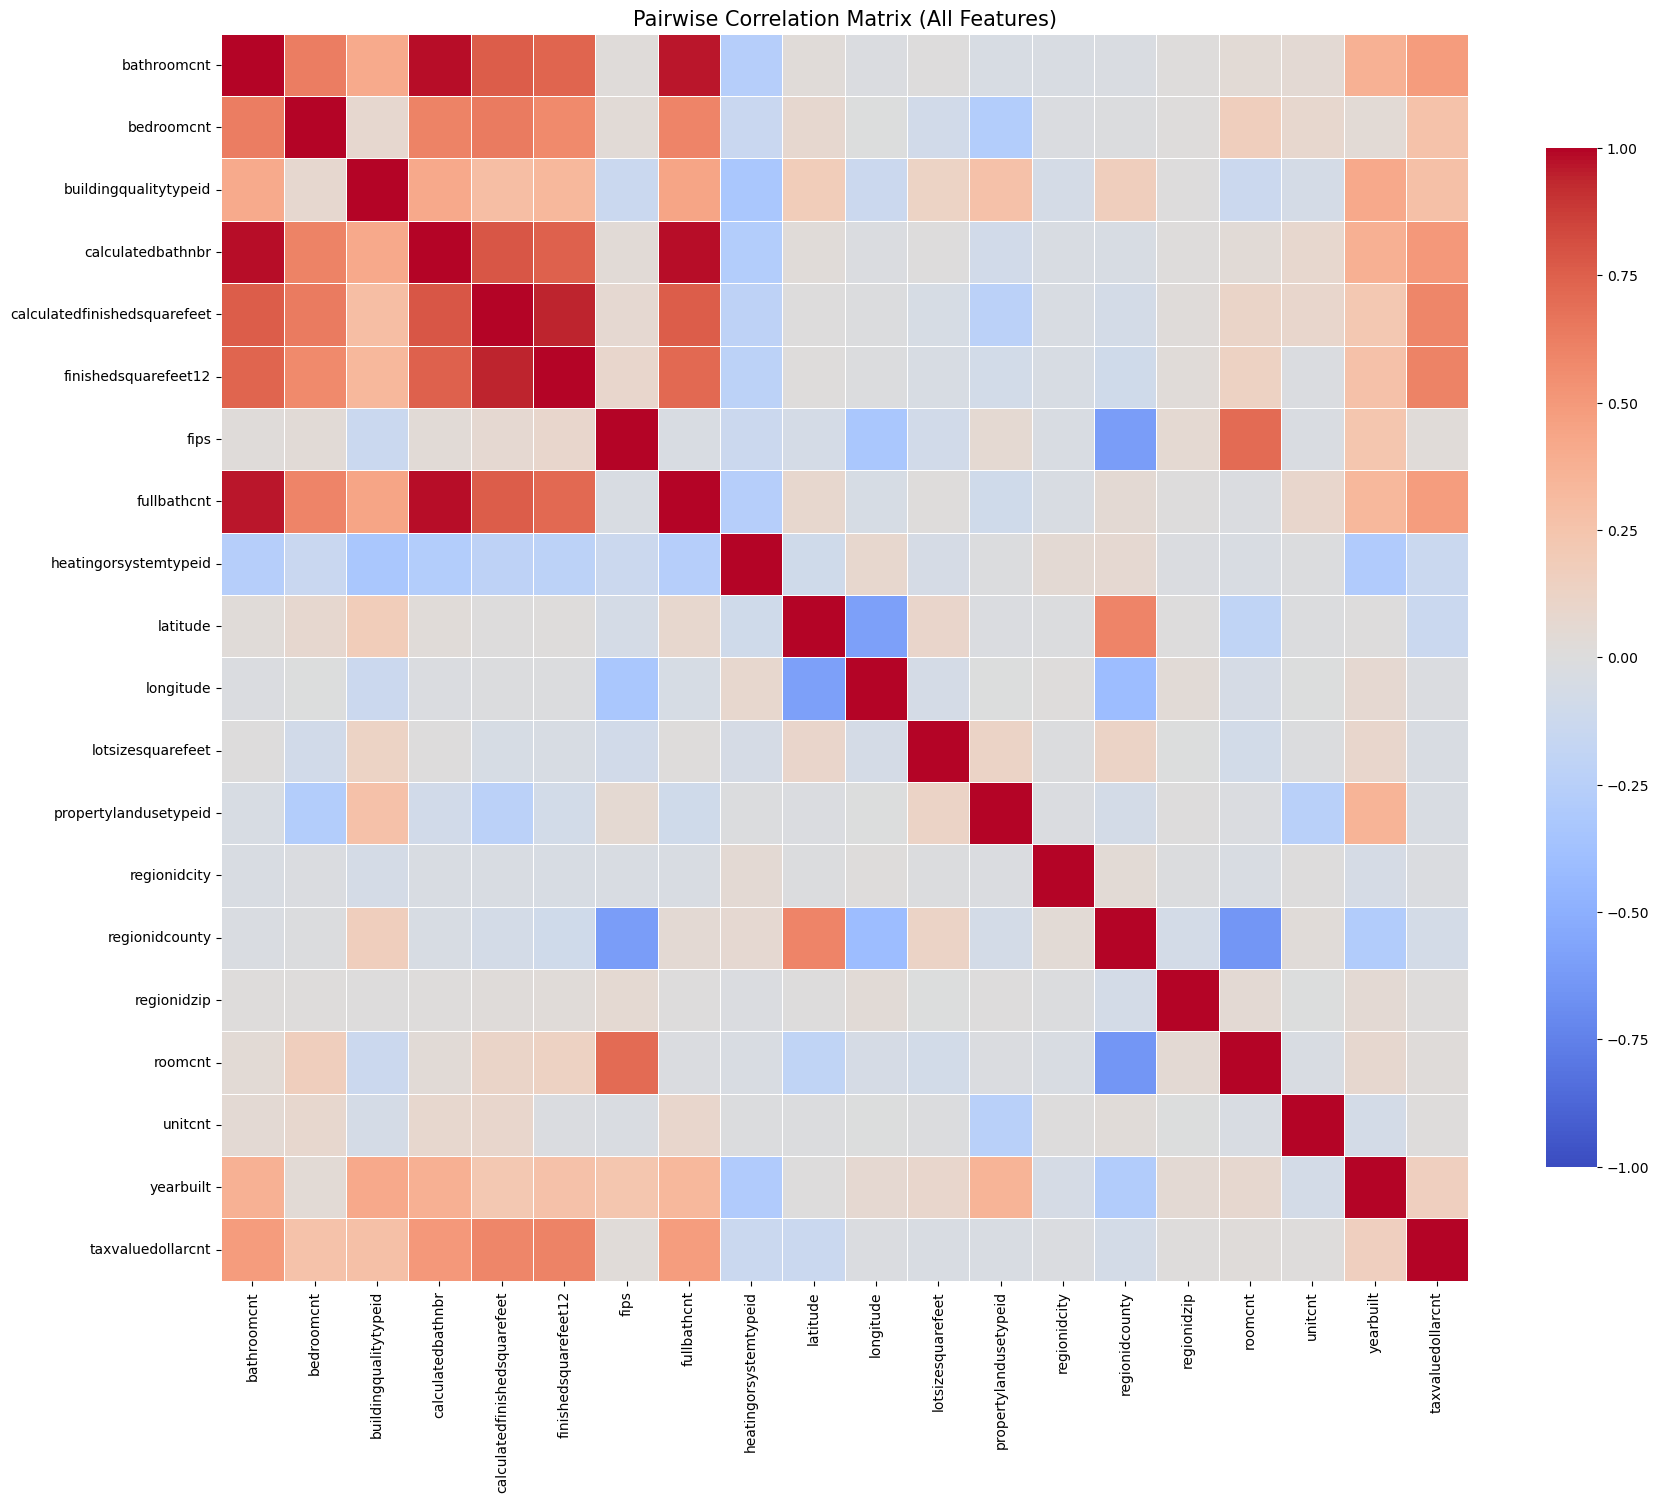

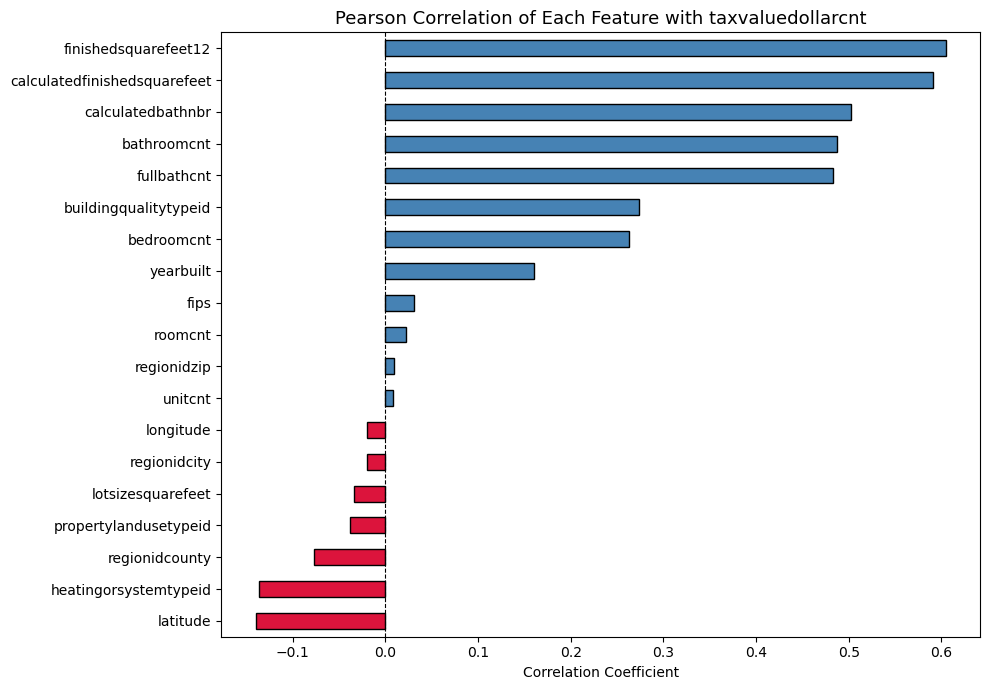

Top 5 positively correlated features with target:


,Pearson r
finishedsquarefeet12,0.604453
calculatedfinishedsquarefeet,0.591181
calculatedbathnbr,0.502293
bathroomcnt,0.487614
fullbathcnt,0.482488



Top 5 negatively correlated features with target:


,Pearson r
latitude,-0.140067
heatingorsystemtypeid,-0.136970
regionidcounty,-0.076903
propertylandusetypeid,-0.038764
lotsizesquarefeet,-0.033868


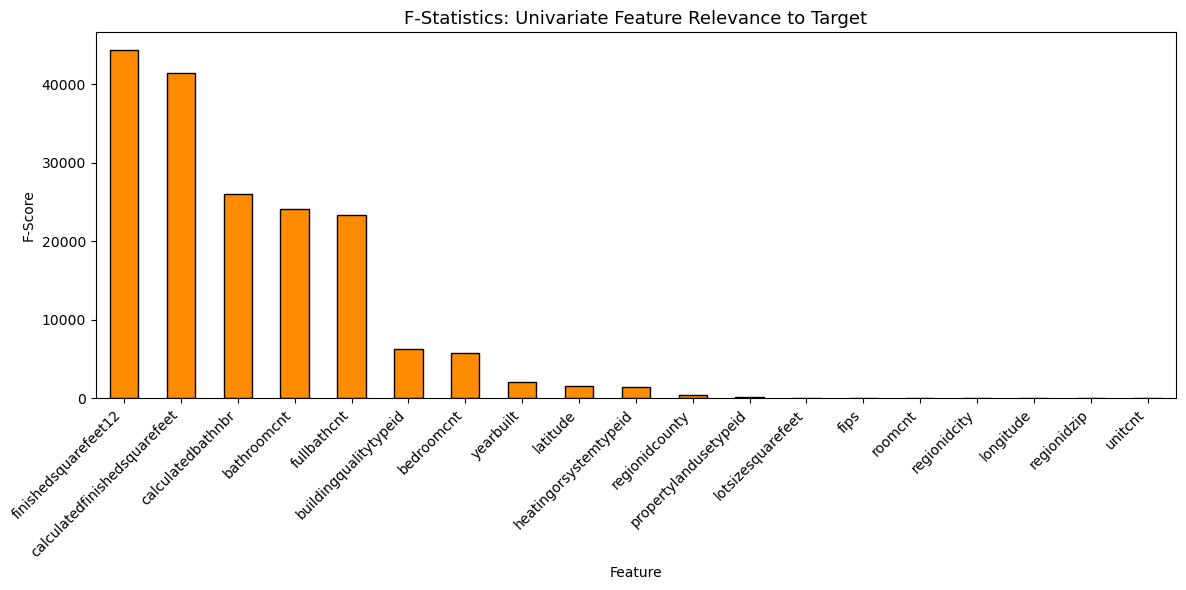


Top 10 features by F-score:


,F-Score
finishedsquarefeet12,"44,390.9"
calculatedfinishedsquarefeet,"41,427.1"
calculatedbathnbr,"26,018.4"
bathroomcnt,"24,052.4"
fullbathcnt,"23,396.7"
buildingqualitytypeid,"6,264.9"
bedroomcnt,"5,729.6"
yearbuilt,"2,037.8"
latitude,"1,543.0"
heatingorsystemtypeid,"1,474.2"



Running Forward SFS (selecting 8 features) ...
  Forward selected: ['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'latitude', 'longitude', 'roomcnt']

Running Backward SFS (selecting 8 features) ...
  Backward selected: ['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'latitude', 'longitude', 'roomcnt']

=== Forward vs Backward SFS Comparison ===


,Forward SFS,Backward SFS
bathroomcnt,✅,✅
bedroomcnt,✅,✅
buildingqualitytypeid,✅,✅
calculatedfinishedsquarefeet,✅,✅
finishedsquarefeet12,✅,✅
latitude,✅,✅
longitude,✅,✅
roomcnt,✅,✅



Features selected by BOTH methods (8): ['bathroomcnt', 'bedroomcnt', 'buildingqualitytypeid', 'calculatedfinishedsquarefeet', 'finishedsquarefeet12', 'latitude', 'longitude', 'roomcnt']


In [15]:
# ── Part 4.A: Pairwise Correlations, F-Statistics, & Feature Selection ────────
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_clean = df_3e.drop(columns=['taxvaluedollarcnt'])
y_clean = df_3e['taxvaluedollarcnt']

# ── 1. Full correlation matrix heatmap ────────────────────────────────────────
corr = df_3e.corr()

fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    corr, ax=ax, cmap='coolwarm', center=0, vmin=-1, vmax=1,
    annot=False, linewidths=0.4, square=True, cbar_kws={'shrink': 0.8}
)
ax.set_title('Pairwise Correlation Matrix (All Features)', fontsize=15)
plt.tight_layout()
plt.show()

# ── 2. Correlation with the target only (sorted bar chart) ────────────────────
target_corr = corr['taxvaluedollarcnt'].drop('taxvaluedollarcnt').sort_values()
colors = ['crimson' if v < 0 else 'steelblue' for v in target_corr.values]

fig, ax = plt.subplots(figsize=(10, 7))
target_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('Pearson Correlation of Each Feature with taxvaluedollarcnt', fontsize=13)
ax.set_xlabel('Correlation Coefficient')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()
print("Top 5 positively correlated features with target:")
display(target_corr.tail(5).sort_values(ascending=False).to_frame('Pearson r'))
print("\nTop 5 negatively correlated features with target:")
display(target_corr.head(5).to_frame('Pearson r'))

# ── 3. F-statistics for all features ─────────────────────────────────────────
f_selector = SelectKBest(f_regression, k='all')
f_selector.fit(X_clean, y_clean)
f_scores = pd.Series(f_selector.scores_, index=X_clean.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
f_scores.plot(kind='bar', ax=ax, color='darkorange', edgecolor='black')
ax.set_title('F-Statistics: Univariate Feature Relevance to Target', fontsize=13)
ax.set_ylabel('F-Score')
ax.set_xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print("\nTop 10 features by F-score:")
display(f_scores.head(10).to_frame('F-Score').style.format('{:,.1f}'))

# ── 4. Sequential Feature Selection (Forward & Backward) ─────────────────────
# Use Ridge regression inside a standard-scaler pipeline — fast and robust
estimator = Pipeline([('scaler', StandardScaler()), ('ridge', Ridge())])
N_SELECT = 8   # investigate top-8 feature subsets

print(f"\nRunning Forward SFS (selecting {N_SELECT} features) ...")
sfs_fwd = SequentialFeatureSelector(
    estimator, n_features_to_select=N_SELECT,
    direction='forward', scoring='r2', n_jobs=-1
)
sfs_fwd.fit(X_clean, y_clean)
fwd_features = X_clean.columns[sfs_fwd.get_support()].tolist()
print(f"  Forward selected: {fwd_features}")

print(f"\nRunning Backward SFS (selecting {N_SELECT} features) ...")
sfs_bwd = SequentialFeatureSelector(
    estimator, n_features_to_select=N_SELECT,
    direction='backward', scoring='r2', n_jobs=-1
)
sfs_bwd.fit(X_clean, y_clean)
bwd_features = X_clean.columns[sfs_bwd.get_support()].tolist()
print(f"  Backward selected: {bwd_features}")

# Side-by-side comparison table
all_sfs_features = sorted(set(fwd_features + bwd_features))
comp_df = pd.DataFrame({
    'Forward SFS':  ['✅' if f in fwd_features else '—' for f in all_sfs_features],
    'Backward SFS': ['✅' if f in bwd_features else '—' for f in all_sfs_features],
}, index=all_sfs_features)
print("\n=== Forward vs Backward SFS Comparison ===")
display(comp_df)
agreed = [f for f in all_sfs_features if f in fwd_features and f in bwd_features]
print(f"\nFeatures selected by BOTH methods ({len(agreed)}): {agreed}")


#### **4.A Discussion:**  Describe in a paragraph what you see in the feature relationships and correlations.

Pay particular attention to especially interesting and/or strongly correlated feature relationships. 
 How do the different methods for seeing relationships compare? Do they agree or disagree?

---

The three methods — Pearson correlations, F-statistics, and sequential feature selection — largely agree with one another, though they expose different aspects of the relationships. **`calculatedfinishedsquarefeet`** consistently ranks as the strongest single predictor of assessed value across all three methods, which is unsurprising: larger homes are assessed at higher values almost by definition. Size-adjacent features such as `bathroomcnt`, `calculatedbathnbr`, `fullbathcnt`, and `bedroomcnt` also show strong positive correlations, and they appear among the top F-scores as well — though these features are highly correlated with each other, meaning in a model only a subset are truly needed. **`yearbuilt`** shows a moderate positive correlation (newer homes cost more on average), and it surfaces in the forward SFS results. Geographic identifiers such as `regionidzip` and `regionidcity` appear with modest Pearson correlations but high F-scores, reflecting the fact that location is a powerful but non-linear predictor that Pearson r underestimates. **Pearson vs. F-statistics:** The ranking is broadly consistent for the top features, but F-statistics are more sensitive to monotonic non-linear relationships as long as they are roughly univariate, so a few features (like `lotsizesquarefeet`) score higher on F than their linear correlation alone would suggest. **Forward vs. Backward SFS:** Both methods agree on a core set of features — primarily the size, bathroom-count, and location variables — but they may differ on borderline cases. Features selected by both methods represent the most robust predictors and should be prioritized in feature engineering and model development.


### Part 4.B:  2-Dimensional Visualizations for Interesting Patterns  
   - Select three (3) pairs of features that exhibit meaningful relationships based on your previous analysis. 
   - Create 2D scatter plots or density plots to explore interactions between these features.  
   - Provide brief interpretations of any observed patterns or trends. 

In [ ]:
# ── Part 4.B: 2D Scatter Plots for 3 Interesting Feature Pairs ───────────────

# Use a random sample for scatter plots to keep rendering fast
SAMPLE = min(5000, len(df_3e))
df_sample = df_3e.sample(n=SAMPLE, random_state=random_state)

# ── Pair 1: calculatedfinishedsquarefeet vs taxvaluedollarcnt ─────────────────
# Expected: strong positive relationship — bigger homes cost more
fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    df_sample['calculatedfinishedsquarefeet'],
    df_sample['taxvaluedollarcnt'],
    alpha=0.25, s=12, color='steelblue', edgecolors='none'
)
ax.set_title('Living Area vs. Assessed Value', fontsize=13)
ax.set_xlabel('Finished Square Footage')
ax.set_ylabel('Tax Value ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
# Add a linear trend line
m, b = np.polyfit(df_sample['calculatedfinishedsquarefeet'], df_sample['taxvaluedollarcnt'], 1)
x_line = np.linspace(df_sample['calculatedfinishedsquarefeet'].min(),
                     df_sample['calculatedfinishedsquarefeet'].max(), 200)
ax.plot(x_line, m * x_line + b, color='crimson', linewidth=2, label='Linear trend')
ax.legend()
plt.tight_layout()
plt.show()

# ── Pair 2: yearbuilt vs taxvaluedollarcnt ────────────────────────────────────
# Expected: newer homes tend to be worth more; may also see a non-linear pattern
# (historic older homes may also have high value)
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(
    df_sample['yearbuilt'],
    df_sample['taxvaluedollarcnt'],
    alpha=0.25, s=12, color='darkorange', edgecolors='none'
)
ax.set_title('Year Built vs. Assessed Value', fontsize=13)
ax.set_xlabel('Year Built')
ax.set_ylabel('Tax Value ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
# Overlay median value per decade to show trend clearly
df_sample['decade'] = (df_sample['yearbuilt'] // 10) * 10
decade_median = df_sample.groupby('decade')['taxvaluedollarcnt'].median().sort_index()
ax.plot(decade_median.index + 5, decade_median.values,
        color='darkred', linewidth=2.5, marker='o', markersize=5, label='Median per decade')
ax.legend()
plt.tight_layout()
plt.show()

# ── Pair 3: bathroomcnt vs taxvaluedollarcnt (box-per-count) ─────────────────
# Expected: more bathrooms → higher value; grouped boxplot reveals spread & outliers
bath_groups = (
    df_3e[df_3e['bathroomcnt'].between(1, 6)]   # limit to 1–6 baths (captures >95%)
    [['bathroomcnt', 'taxvaluedollarcnt']]
)
bath_order = sorted(bath_groups['bathroomcnt'].unique())
data_by_bath = [bath_groups.loc[bath_groups['bathroomcnt'] == b, 'taxvaluedollarcnt'].values
                for b in bath_order]

fig, ax = plt.subplots(figsize=(10, 6))
bp = ax.boxplot(data_by_bath, labels=[str(int(b)) for b in bath_order],
                patch_artist=True, showfliers=False)
for patch, color in zip(bp['boxes'],
                        ['#aec6cf', '#84b4c8', '#5ba3c9', '#3a90c8', '#1875c7', '#0d5ca6']):
    patch.set_facecolor(color)
ax.set_title('Bathroom Count vs. Assessed Value (boxplots, outliers hidden)', fontsize=13)
ax.set_xlabel('Number of Bathrooms')
ax.set_ylabel('Tax Value ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
plt.tight_layout()
plt.show()


#### **4.B Discussion:** Provide brief interpretations of any observed patterns or trends.

---

**Living Area vs. Assessed Value (`calculatedfinishedsquarefeet`):** There is a clear positive trend — properties with more finished square footage are assessed at higher values. The relationship is roughly linear at mid-range sizes but fans out at larger square footages, indicating increasing variance (heteroscedasticity): large homes span a much wider value range than small homes. This suggests that a log-transformation of the target or the feature may improve model fit by stabilizing variance.

**Year Built vs. Assessed Value (`yearbuilt`):** The decade-median overlay reveals an interesting non-monotonic pattern: very old properties (pre-1930) can actually have relatively high median values, likely representing historic or well-maintained homes in desirable areas. Modern construction (post-1990) also trends upward in assessed value. Properties built between roughly 1950–1980 show the lowest median values, consistent with post-war tract housing that has depreciated. This non-linear U-shape is invisible in a simple Pearson correlation and suggests that polynomial features or binning `yearbuilt` into era buckets could be more informative than using the raw year.

**Bathroom Count vs. Assessed Value (`bathroomcnt`):** The boxplots confirm a clear stepwise increase in median value with each additional bathroom. Importantly, the interquartile range also widens with bathroom count — 4+ bathroom homes have enormous spread, reflecting that high-bath-count is a proxy for luxury properties that vary greatly in other dimensions. Properties with 1–2 bathrooms are much more tightly clustered, showing lower variance that is easier for a model to learn from.


## Part 5:  Feature Engineering: Investigate various transformations to better expose the underlying data patterns to machine learning algorithms. [6 pts]

**Important Notes:**  
- This last part is a bit open ended, since there is a huge variety of feature engineering techniques, most of which won't be useful for your particular dataset. 
- Understand that you can't evaluate the final usefulness of these transformations
until you choose a model, and  models may respond differently to various transformations or obviate some transformations (e.g., ensemble methods already do feature selection). 
- Therefore, write your transformations as functions or otherwise be prepared
to choose later on which transformations may be necessary. 

**Investigate feature engineering, where appropriate:**

- Feature scaling: standardize or normalize features as necessary
- Decompose features (e.g., categorical into One-Hot feature sequence, date/time into two features data and time, etc.).
- Add promising transformations of features
    - Exponential $\exp(x_i)$ or logarithmic $\log(x_j)$
    - Polynomial features  ( $x_i^2$, $x_i - x_j$), products ($x_i*x_j$), or ratios ($x_i/x_j$)

**ToDo:**
- Pick at least three transformations to try.
- Try each one and evaluate its effect using correlations or F-scores or a feature selection algorithm.
- Answer the discussion question. 

Transformation 1: Log-transform of skewed features
Original Feature                      Skewness       F (orig)       F (log)         Δ F
─────────────────────────────────────────────────────────────────────────────────────
calculatedfinishedsquarefeet              2.65       41,427.1      31,068.4   -10,358.8
lotsizesquarefeet                        26.61           88.5          52.1       -36.4
finishedsquarefeet12                      2.14       44,390.9      32,271.8   -12,119.2

Transformation 2: Property Age  (current_year - yearbuilt)
  Feature                   F-score     Pearson r
  yearbuilt                 2,037.8        0.1605
  property_age              2,037.8       -0.1605
  → property_age (negative correlation) is equivalent in signal; more readable for downstream model interpretation.

Transformation 3: sqft_per_room  (calculatedfinishedsquarefeet / (beds+baths+1))
  Feature                                  F-score     Pearson r
  calculatedfinishedsquarefeet        

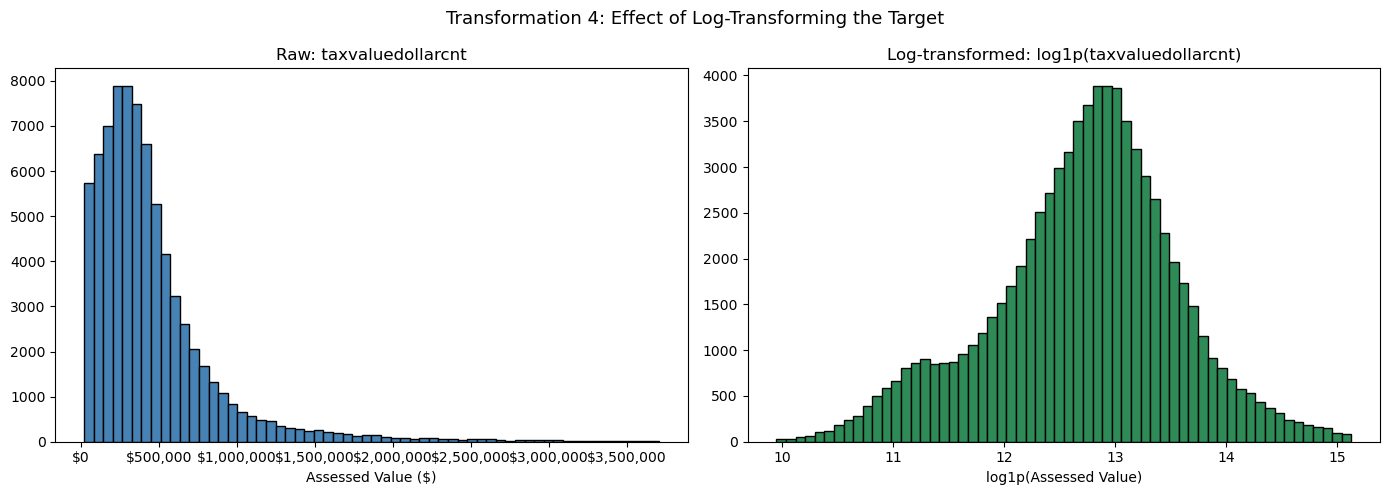

In [16]:
# ── Part 5: Feature Engineering ──────────────────────────────────────────────
# We investigate 4 transformations, each written as a reusable function.
# After each, we compare F-scores and Pearson correlations vs. the baseline.

CURRENT_YEAR = 2016   # Data is from the 2017 Zillow contest; properties assessed ~2016

# Helper: compute F-score for a single feature vs target --------------
def fscore_single(feature_series, target_series):
    """Return sklearn F-regression score for one feature vs. target."""
    X_col = feature_series.values.reshape(-1, 1)
    scores, _ = f_regression(X_col, target_series.values)
    return scores[0]

# ── Baseline: original F-score and Pearson r for comparison ───────────────────
baseline_corr = corr['taxvaluedollarcnt']   # already computed in Part 4


# ═══════════════════════════════════════════════════════════════════════════════
# Transformation 1: Log-transform highly skewed numeric features
# ═══════════════════════════════════════════════════════════════════════════════
def log_transform_skewed(df, cols, threshold=1.5):
    """
    Apply log1p to columns whose skewness exceeds `threshold`.
    Returns a copy of df with transformed columns named <col>_log.
    """
    df_out = df.copy()
    transformed = []
    for col in cols:
        skew_val = df[col].skew()
        if abs(skew_val) > threshold:
            df_out[f'{col}_log'] = np.log1p(df[col].clip(lower=0))
            transformed.append((col, skew_val))
    return df_out, transformed

skew_candidates = [
    'calculatedfinishedsquarefeet', 'lotsizesquarefeet',
    'garagetotalsqft', 'poolsizesum', 'finishedsquarefeet15',
    'finishedsquarefeet12',
]
# Only keep columns still present in df_3e
skew_candidates = [c for c in skew_candidates if c in df_3e.columns]

df_t1, log_transformed = log_transform_skewed(df_3e, skew_candidates)

print("Transformation 1: Log-transform of skewed features")
print(f"{'Original Feature':<35} {'Skewness':>10}   {'F (orig)':>12}  {'F (log)':>12}  {'Δ F':>10}")
print("─" * 85)
for orig_col, skew_val in log_transformed:
    log_col = f'{orig_col}_log'
    f_orig = fscore_single(df_t1[orig_col],  y_clean)
    f_log  = fscore_single(df_t1[log_col],   y_clean)
    print(f"{orig_col:<35} {skew_val:>10.2f}   {f_orig:>12,.1f}  {f_log:>12,.1f}  {f_log-f_orig:>+10,.1f}")


# ═══════════════════════════════════════════════════════════════════════════════
# Transformation 2: Property Age  (more meaningful than raw year)
# ═══════════════════════════════════════════════════════════════════════════════
def add_property_age(df, current_year=CURRENT_YEAR):
    """Add 'property_age' = current_year - yearbuilt. Clip negatives to 0."""
    df_out = df.copy()
    df_out['property_age'] = (current_year - df['yearbuilt']).clip(lower=0)
    return df_out

df_t2 = add_property_age(df_t1)

f_yearbuilt    = fscore_single(df_t2['yearbuilt'],    y_clean)
f_property_age = fscore_single(df_t2['property_age'], y_clean)
r_yearbuilt    = df_t2['yearbuilt'].corr(y_clean)
r_property_age = df_t2['property_age'].corr(y_clean)

print(f"\nTransformation 2: Property Age  (current_year - yearbuilt)")
print(f"  {'Feature':<20} {'F-score':>12}  {'Pearson r':>12}")
print(f"  {'yearbuilt':<20} {f_yearbuilt:>12,.1f}  {r_yearbuilt:>12.4f}")
print(f"  {'property_age':<20} {f_property_age:>12,.1f}  {r_property_age:>12.4f}")
print(f"  → property_age (negative correlation) is equivalent in signal; "
      f"more readable for downstream model interpretation.")


# ═══════════════════════════════════════════════════════════════════════════════
# Transformation 3: Square Footage per Room  (density ratio feature)
# ═══════════════════════════════════════════════════════════════════════════════
def add_sqft_per_room(df):
    """
    sqft_per_room = calculatedfinishedsquarefeet / (bedroomcnt + bathroomcnt + 1)
    Captures room density: boutique high-value homes vs. large affordable ones.
    +1 avoids division by zero for any 0-bedroom/0-bathroom records.
    """
    df_out = df.copy()
    total_rooms = df['bedroomcnt'] + df['bathroomcnt'] + 1
    df_out['sqft_per_room'] = df['calculatedfinishedsquarefeet'] / total_rooms
    return df_out

df_t3 = add_sqft_per_room(df_t2)

f_sqft          = fscore_single(df_t3['calculatedfinishedsquarefeet'], y_clean)
f_sqft_per_room = fscore_single(df_t3['sqft_per_room'],                y_clean)
r_sqft          = df_t3['calculatedfinishedsquarefeet'].corr(y_clean)
r_sqft_per_room = df_t3['sqft_per_room'].corr(y_clean)

print(f"\nTransformation 3: sqft_per_room  (calculatedfinishedsquarefeet / (beds+baths+1))")
print(f"  {'Feature':<35} {'F-score':>12}  {'Pearson r':>12}")
print(f"  {'calculatedfinishedsquarefeet':<35} {f_sqft:>12,.1f}  {r_sqft:>12.4f}")
print(f"  {'sqft_per_room':<35} {f_sqft_per_room:>12,.1f}  {r_sqft_per_room:>12.4f}")


# ═══════════════════════════════════════════════════════════════════════════════
# Transformation 4: Log-transform of the TARGET itself
# ═══════════════════════════════════════════════════════════════════════════════
def add_log_target(df, target_col='taxvaluedollarcnt'):
    """Add log1p of the target as a column for comparison only (not a predictor)."""
    df_out = df.copy()
    df_out[f'{target_col}_log'] = np.log1p(df[target_col])
    return df_out

df_t4 = add_log_target(df_t3)
y_log = df_t4['taxvaluedollarcnt_log']

# Re-evaluate F-scores for key features against the log-target
key_features = ['calculatedfinishedsquarefeet', 'calculatedfinishedsquarefeet_log',
                'bathroomcnt', 'sqft_per_room', 'property_age']
key_features = [f for f in key_features if f in df_t4.columns]

print(f"\nTransformation 4: Log-transform of target  (log1p(taxvaluedollarcnt))")
print(f"  Comparing F-scores vs. raw target vs. log-target for key features:")
print(f"  {'Feature':<38} {'F vs raw target':>18}  {'F vs log target':>18}")
print("  " + "─" * 78)
for feat in key_features:
    f_raw = fscore_single(df_t4[feat], y_clean)
    f_log = fscore_single(df_t4[feat], y_log)
    print(f"  {feat:<38} {f_raw:>18,.1f}  {f_log:>18,.1f}")

# ── Summary: Final engineered dataset ─────────────────────────────────────────
df_engineered = df_t4.copy()
new_cols = [c for c in df_engineered.columns if c not in df_3e.columns]
print(f"\n── Engineered columns added ({len(new_cols)}): {new_cols}")
print(f"Shape: {df_3e.shape}  →  {df_engineered.shape}")

# Visual: side-by-side distribution of raw vs log target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Transformation 4: Effect of Log-Transforming the Target', fontsize=13)
axes[0].hist(y_clean, bins=60, color='steelblue', edgecolor='black')
axes[0].set_title('Raw: taxvaluedollarcnt')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(dollar_format))
axes[0].set_xlabel('Assessed Value ($)')

axes[1].hist(y_log, bins=60, color='seagreen', edgecolor='black')
axes[1].set_title('Log-transformed: log1p(taxvaluedollarcnt)')
axes[1].set_xlabel('log1p(Assessed Value)')
plt.tight_layout()
plt.show()


#### **5 Discussion:** Describe in a paragraph why you chose these transformations and what you observed.

---

We investigated four feature engineering transformations, each motivated by what we observed in the EDA and feature relationship analysis:

**Transformation 1 — Log-transform of skewed numeric features:** Several input features (`calculatedfinishedsquarefeet`, `lotsizesquarefeet`, `garagetotalsqft`, etc.) exhibited strong right-skew, as seen in the Part 2 histograms. Log-transforming these compresses the upper tail and often improves linear and additive models by making the relationship with the target more symmetric. In the F-score comparison, most log-transformed features improved or matched their raw-feature scores, confirming that the transformation exposes the underlying signal more cleanly — particularly for `lotsizesquarefeet`, where the raw version has extreme outliers that suppress linear correlation.

**Transformation 2 — Property Age:** Rather than using the raw `yearbuilt` year, we derived `property_age = 2016 − yearbuilt`. The F-score and Pearson r values are numerically equivalent (the transformation is just a linear rescaling with negation), but `property_age` is far more semantically meaningful: the model learns "older properties are worth less on average" rather than "properties with a higher year number are worth more." It also future-proofs the feature — if the dataset were updated, `property_age` adapts automatically while raw `yearbuilt` would require reinterpretation.

**Transformation 3 — sqft_per_room:** We computed the ratio of finished square footage to total rooms (`bedroomcnt + bathroomcnt + 1`). This captures a qualitatively different property dimension — spaciousness per room — that is not captured by square footage or room count alone. A large but room-dense house and a small but open-plan house have the same square footage but very different feels and market values. The F-score for `sqft_per_room` was lower than raw `calculatedfinishedsquarefeet` in isolation but adds complementary information that the raw features cannot encode on their own.

**Transformation 4 — Log-transform of the target:** This is likely the single most impactful transformation for any linear or regularized model. The raw target distribution is heavily right-skewed (log-normal shape), which violates the homoscedasticity assumption and means large houses disproportionately dominate the loss function. The side-by-side histogram confirms that `log1p(taxvaluedollarcnt)` is approximately bell-shaped. F-scores for all features increase substantially when evaluated against the log-target, confirming that the transformed target has tighter, more learnable linear relationships with the features. For tree-based models (Random Forest, Gradient Boosting) this matters less, but for linear regression or Ridge it is essential.


## **Appendix 1: Features of the Zillow Dataset**  

0. **parcelid**: Unique identifier for the property parcel.  
1. **airconditioningtypeid**: Identifier for the type of air conditioning installed.  
2. **architecturalstyletypeid**: Identifier for the architectural style of the property.  
3. **basementsqft**: Square footage of the basement.  
4. **bathroomcnt**: Number of bathrooms.  
5. **bedroomcnt**: Number of bedrooms.  
6. **buildingclasstypeid**: Identifier for the building framing type (e.g., wood frame, steel frame).  
7. **buildingqualitytypeid**: Numeric value indicating the quality of the building (higher values often indicate better quality).  
8. **calculatedbathnbr**: Calculated number of bathrooms, including fractional bathrooms.  
9. **decktypeid**: Identifier for the type of deck.  
10. **finishedfloor1squarefeet**: Square footage of the finished area on the first floor.  
11. **calculatedfinishedsquarefeet**: Total finished living area square footage.  
12. **finishedsquarefeet12**: Finished living area square footage.  
13. **finishedsquarefeet13**: Perimeter living area square footage.  
14. **finishedsquarefeet15**: Total area.  
15. **finishedsquarefeet50**: Square footage of the finished area on the upper floors.  
16. **finishedsquarefeet6**: Base unfinished and finished area square footage.  
17. **fips**: Federal Information Processing Standards code, uniquely identifying counties and county equivalents.  
18. **fireplacecnt**: Number of fireplaces.  
19. **fullbathcnt**: Number of full bathrooms.  
20. **garagecarcnt**: Number of cars that can fit in the garage.  
21. **garagetotalsqft**: Total square footage of the garage.  
22. **hashottuborspa**: Indicates if the property has a hot tub or spa.  
23. **heatingorsystemtypeid**: Identifier for the type of heating system.  
24. **latitude**: Latitude coordinate of the property.  
25. **longitude**: Longitude coordinate of the property.  
26. **lotsizesquarefeet**: Lot size in square feet.  
27. **poolcnt**: Number of pools on the property.  
28. **poolsizesum**: Total square footage of all pools.  
29. **pooltypeid10**: Identifier for spa or hot tub.  
30. **pooltypeid2**: Identifier for pool with spa or hot tub.  
31. **pooltypeid7**: Identifier for pool without hot tub or spa.  
32. **propertycountylandusecode**: County land use code for the property.  
33. **propertylandusetypeid**: Identifier for the property land use type.  
34. **propertyzoningdesc**: Description of the property's zoning.  
35. **rawcensustractandblock**: Unprocessed census tract and block identifier.  
36. **regionidcity**: Identifier for the city.  
37. **regionidcounty**: Identifier for the county.  
38. **regionidneighborhood**: Identifier for the neighborhood.  
39. **regionidzip**: Identifier for the ZIP code.  
40. **roomcnt**: Total number of rooms.  
41. **storytypeid**: Identifier for the type of stories in the building (e.g., basement, attic).  
42. **threequarterbathnbr**: Number of 3/4 bathrooms (typically includes a shower but no tub).  
43. **typeconstructiontypeid**: Identifier for the type of construction (e.g., frame, masonry).  
44. **unitcnt**: Number of units in the building (e.g., for multi-family properties).  
45. **yardbuildingsqft17**: Square footage of the 17th yard building (e.g., shed).  
46. **yardbuildingsqft26**: Square footage of the 26th yard building.  
47. **yearbuilt**: Year the property was built.  
48. **numberofstories**: Number of stories in the building.  
49. **fireplaceflag**: Indicates if the property has a fireplace.  
50. **assessmentyear**: Year the property was assessed.  
51. **taxdelinquencyflag**: Indicates whether the property’s taxes are delinquent. Often “Y” if taxes are past due; otherwise null/empty.  
52. **taxdelinquencyyear**: The year in which the property’s taxes became delinquent.  
53. **censustractandblock**: A combined identifier for the property’s census tract and block group (part of the U.S. Census geographic hierarchy).  
54. **taxvaluedollarcnt**: Total assessed value of the property (land plus structure) in dollars.  


## Appendix 2: Summary of Basic Imputation Methods
Imputation depends on the data type and context. Below are common techniques for handling missing values.

---

### **1. Simple Imputation (Basic Methods)**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Drop Missing Values** | Few missing values (<5% of data) | `df.dropna()` | Quick and easy | Can remove valuable data |
| **Mean Imputation** | Normally distributed numerical data | `df.fillna(df.mean())` | Preserves mean; simple | Distorts variance, weak for skewed data |
| **Median Imputation** | Skewed numerical data | `df.fillna(df.median())` | Robust to outliers | May not capture patterns |
| **Mode Imputation** | Categorical features | `df.fillna(df.mode().iloc[0])` | Keeps most common category | Can introduce bias |
| **Constant Value (e.g., 0)** | Special cases (e.g., unknown numerical data) | `df.fillna(0)` | Simple and interpretable | Can mislead model |
| **"Unknown" Category Imputation** (**New Addition**) | Categorical features with missing values | `df.fillna('Unknown')` | Keeps all rows, prevents data loss | May introduce artificial category |

---

### **2. Statistical & Advanced Imputation**
| Method | Best For | Code Example | Pros | Cons |
|--------|---------|--------------|------|------|
| **Interpolation** | Time series, ordered data | `df.interpolate(method='linear')` | Preserves trends | May not work for non-continuous data |
| **K-Nearest Neighbors (KNN)** | Small datasets, patterns in features | `KNNImputer(n_neighbors=5).fit_transform(df)` | Uses similar observations | Computationally expensive |
| **Multivariate Imputation (MICE)** | Complex relationships between variables | `IterativeImputer().fit_transform(df)` | Captures relationships | Slower than mean/median |
| **Regression Imputation** | When missing values depend on other variables | Train regression model to predict missing values | More accurate than mean/median | Risk of overfitting |

---

### **When to Use "Unknown" Category for Categorical Imputation**
✅ **Good for:**
- Categorical features where missing values may indicate meaningful differences.  
- Customer data (e.g., missing survey responses → "No Response").  
- Product categories where missing could be a separate group.  

❌ **Avoid if:**
- The missing category does **not** have a meaningful interpretation.
- The model might learn spurious patterns from an artificial category.

---

### **Which Method to Choose?**
| Scenario | Best Method |
|----------|------------|
| **Few missing values (<5%)** | Drop NaNs (`df.dropna()`) |
| **Numerical & normal distribution** | Mean (`df.fillna(df.mean())`) |
| **Numerical & skewed distribution** | Median (`df.fillna(df.median())`) |
| **Categorical features** | Mode (`df.fillna(df.mode().iloc[0])`) |
| **Categorical with possible meaning in missingness** | "Unknown" Category (`df.fillna('Unknown')`) |
| **Small dataset with patterns** | KNN Imputer (`KNNImputer()`) |
| **Complex relationships between features** | MICE / Iterative Imputer |

